<a href="https://colab.research.google.com/github/medistlabo/TCGA_Practice/blob/main/tcga_practice_day17_logrank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=f25f19357342be5093145815f49cddb3e9cfee7ce807a4e1c8f7fcc1f40eae4b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [5]:
data = {
    "patient": ["P1","P2","P3","P4","P5","P6","P7","P8","P9","P10",
                "P11","P12","P13","P14","P15","P16"],

    "expression": [5,12,18,25,30,7,40,22,15,35,28,10,45,8,33,20],

    "survival_month": [50,40,35,20,15,45,10,25,38,12,18,48,8,52,14,28],

    "status": [0,0,1,1,1,0,1,1,0,1,1,0,1,0,1,1]
}

df = pd.DataFrame(data)

In [7]:
df["group_median"] = df["expression"].apply(
    lambda x:"High"
    if x >= df["expression"].median()
    else "Low"
)

In [8]:
high_median = df[df["group_median"] == "High"]
low_median = df[df["group_median"] == "Low"]

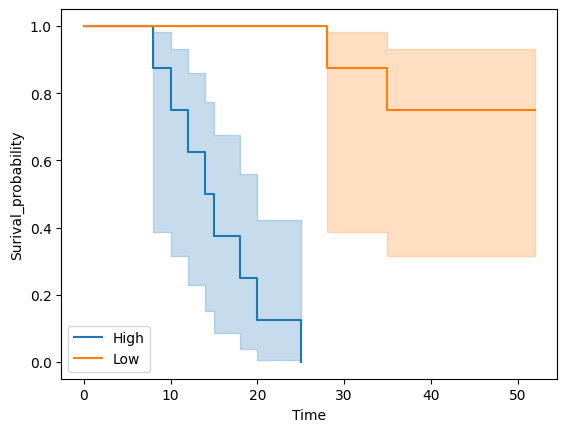

In [12]:
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

kmf_high.fit(
    high_median["survival_month"],
    high_median["status"],
    label = "High"
)

kmf_low.fit(
    low_median["survival_month"],
    low_median["status"],
    label = "Low"
)

ax = kmf_high.plot()
kmf_low.plot(ax = ax)

plt.xlabel("Time")
plt.ylabel("Surival_probability")

plt.show()

High群は予後不良っぽいか？→Yes


In [13]:
results = logrank_test(
    high_median["survival_month"],
    low_median["survival_month"],
    event_observed_A=high_median["status"],
    event_observed_B=low_median["status"]
)

results.print_summary()

KM曲線とp値は一致しているか？→Maybe